## NEURAL NETWORKS

In [1]:
import torch
import torch.nn as nn
import dataloader as dl
import torch.optim as SGD
import torch.nn.init as init
import matplotlib.pyplot as plt
import numpy as np

## Creating neural netwrok layers

In [2]:
layer1 = nn.Linear(28*28, 128)
layer2 = nn.Linear(128, 64)
layer3 = nn.Linear(64, 10)

## Initializing weights and biases using he initialization

In [3]:
init.kaiming_uniform_(layer1.weight, nonlinearity='relu')
init.kaiming_uniform_(layer2.weight, nonlinearity='relu')
init.kaiming_uniform_(layer3.weight)

Parameter containing:
tensor([[ 2.4649e-01,  2.2376e-01,  5.9169e-02,  1.8277e-01, -2.7023e-01,
          1.3475e-01,  1.0069e-01,  1.9614e-01, -1.8473e-01,  3.3800e-02,
          1.3679e-01, -2.4920e-02, -3.5533e-02, -2.2392e-02,  2.4273e-01,
          2.8829e-01, -8.9376e-02,  1.9827e-01,  1.7010e-01,  6.0893e-02,
          2.0793e-01, -1.2425e-01,  3.0387e-01, -1.4224e-01, -1.1908e-01,
          1.3051e-01,  1.1104e-01, -4.1218e-02,  4.0584e-02,  2.9214e-01,
         -1.0618e-01,  2.6834e-01,  1.2456e-01, -1.3843e-01,  1.7494e-01,
         -7.2793e-02, -2.6353e-01, -2.8989e-01,  1.7077e-01,  2.6028e-01,
         -6.0881e-02, -2.3770e-01,  2.4774e-01, -9.2569e-04, -3.0368e-01,
         -2.7474e-01, -1.4547e-01,  2.3194e-01,  3.0283e-01,  7.9046e-02,
          7.8863e-02,  2.8131e-01, -2.5900e-01, -1.8637e-01, -3.0531e-01,
          1.6994e-01, -1.5553e-01, -4.4002e-02,  1.4984e-01,  2.1110e-01,
          1.2315e-01, -1.7672e-01,  3.0014e-01,  2.6082e-01],
        [-6.7976e-03,  3.026

## Creating the neural network model

In [4]:
neural_network = nn.Sequential(
    layer1,
    nn.ReLU(),
    layer2,
    nn.ReLU(),
    layer3,
)


# Training the model

### Setting up the loss function and optimizer

In [5]:

num_epochs = 20
loss_function = None
optimizer = None
loader= None
train_losses = []
val_losses = []
train_accs = []
val_accs = []
test_acc_list = []

# Mocing the model to Gpu to make it faster
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
neural_network.to(device)


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

### function to set the HyperParameters

In [6]:
def parameter_setter(learning_rate=.01,num_epochs=20,batch_size=64):
   global loss_function, optimizer, loader
   loss_function = nn.CrossEntropyLoss()
   optimizer = SGD.SGD(neural_network.parameters(), lr=learning_rate)
   loader=dl.build_loader(batch_size)

### function to clear the neural Network

In [7]:
def clear_nn():
  init.kaiming_uniform_(layer1.weight, nonlinearity='relu')
  init.kaiming_uniform_(layer2.weight, nonlinearity='relu')
  init.kaiming_uniform_(layer3.weight)
  neural_network = nn.Sequential(
    layer1,
    nn.ReLU(),
    layer2,
    nn.ReLU(),
    layer3,
)
  global train_losses, val_losses, train_accs, val_accs
  train_losses = []
  val_losses = []
  train_accs = []
  val_accs = []
  test_acc_list = []

In [8]:

parameter_setter()

def train_model():
    clear_nn()
    for epoch in range(num_epochs):
        neural_network.train()
        # TRAINING
        train_loss = 0
        train_correct = 0
        train_total = 0

        for data, target in loader['train_loader_linear']:
            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            output = neural_network(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()

        # VALIDATION
        neural_network.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in loader['val_loader_linear']:
                data = data.to(device)
                target = target.to(device)

                output = neural_network(data)
                loss = loss_function(output, target)

                val_loss += loss.item()
                _, predicted = torch.max(output, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()

        # Calculate averages
        train_loss = train_loss / len(loader['train_loader_nn'])
        val_loss = val_loss / len(loader['val_loader_nn'])
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Print progress
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
train_model()


Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.9558 | Train Acc: 76.47%
  Val Loss: 0.4928 | Val Acc: 86.34%
Epoch 2/20
  Train Loss: 0.4140 | Train Acc: 88.70%
  Val Loss: 0.3701 | Val Acc: 89.37%
Epoch 3/20
  Train Loss: 0.3380 | Train Acc: 

## Training and Validation Loss

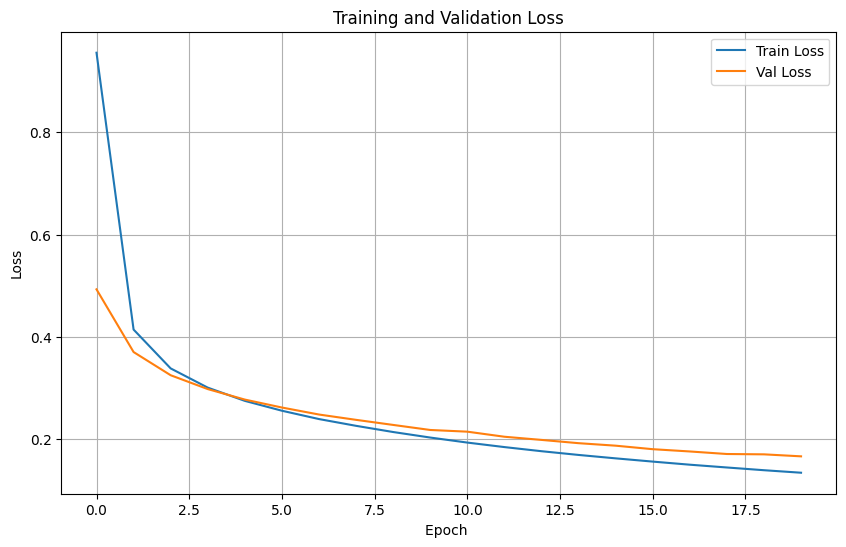

In [9]:
def plot_loss(text):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_loss('')

## Training and Validation Accuracy

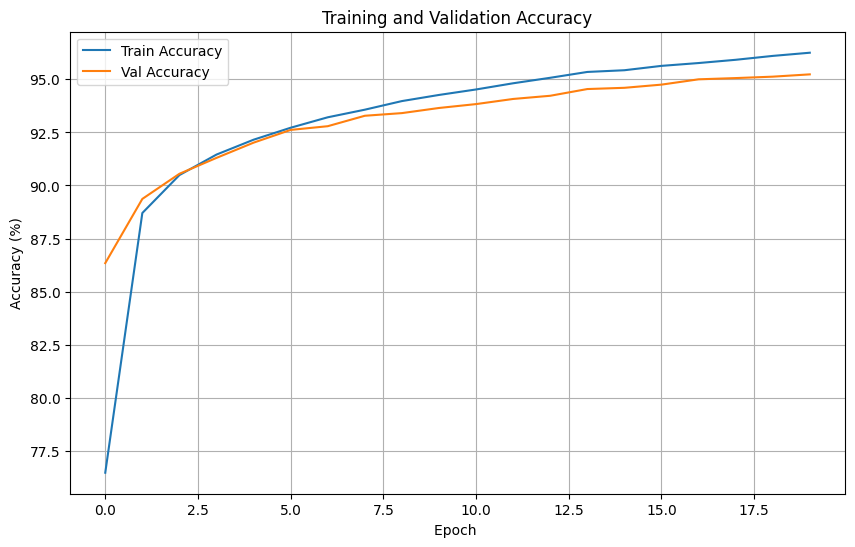

In [10]:

def plot_acc(text):
    plt.figure(figsize=(10, 6))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_acc('')



## Learning Curves with Error Bars

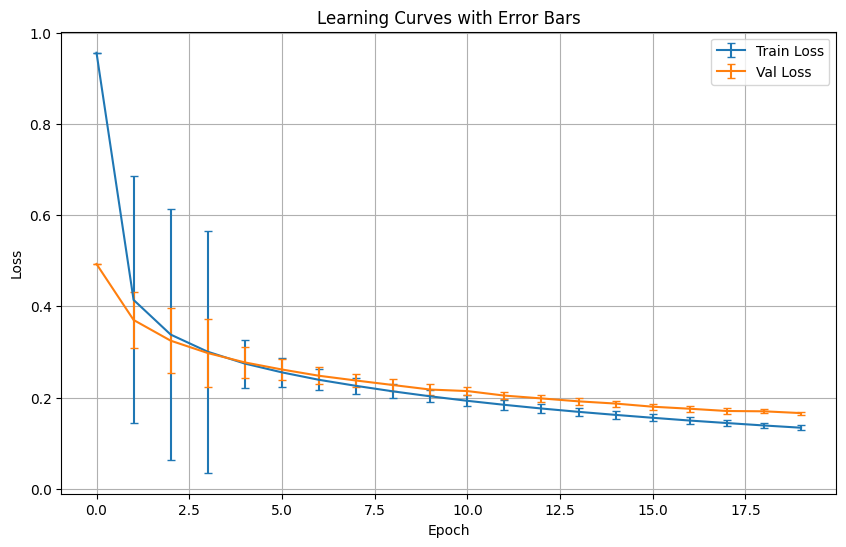

In [11]:

window = 3
train_std = [np.std(train_losses[max(0,i-window):i+1]) for i in range(len(train_losses))]
val_std = [np.std(val_losses[max(0,i-window):i+1]) for i in range(len(val_losses))]

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(train_losses)), train_losses, yerr=train_std, label='Train Loss', capsize=3)
plt.errorbar(range(len(val_losses)), val_losses, yerr=val_std, label='Val Loss', capsize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves with Error Bars')
plt.legend()
plt.grid(True)
plt.show()


## Convergence Analysis

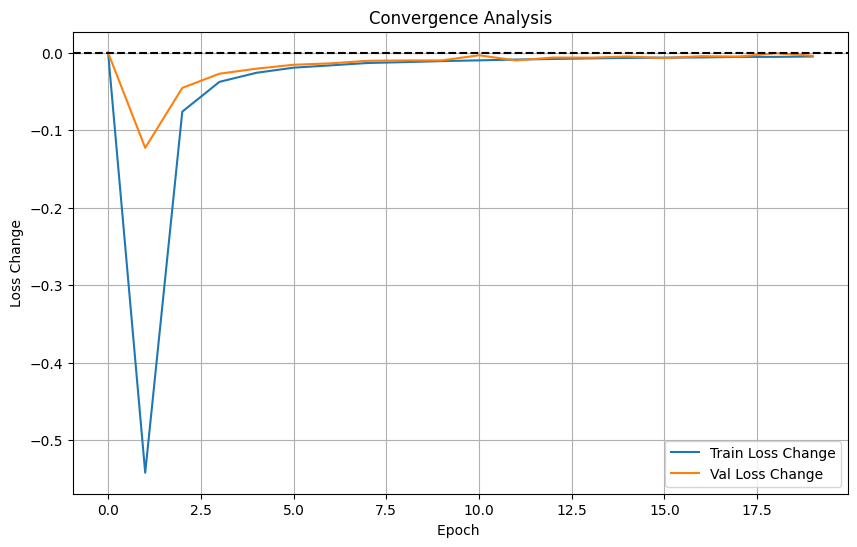

In [12]:

def plot_converge(text):
    train_change = [0] + [train_losses[i] - train_losses[i-1] for i in range(1, len(train_losses))]
    val_change = [0] + [val_losses[i] - val_losses[i-1] for i in range(1, len(val_losses))]

    plt.figure(figsize=(10, 6))
    plt.plot(train_change, label='Train Loss Change')
    plt.plot(val_change, label='Val Loss Change')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss Change')
    plt.title('Convergence Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_converge('')

## Testing the model

In [13]:


def predict_test():
    for data, target in loader['test_loader_linear']:
        data = data.to(device)
        target = target.to(device)

        output = neural_network(data)
        _, predicted = torch.max(output, 1)

        test_total = target.size(0)
        test_correct = (predicted == target).sum().item()

        test_acc = 100 * test_correct / test_total
        test_acc_list.append(test_acc)

    average_test_acc = sum(test_acc_list) / len(test_acc_list)

    print(f'Average Test Accuracy over all batches: {average_test_acc:.2f}%')
predict_test()

Average Test Accuracy over all batches: 95.27%


# Hyperparameter Analysis

## Learning Rate

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 2.0704 | Train Acc: 35.02%
  Val Loss: 1.8202 | Val Acc: 52.69%
Epoch 2/20
  Train Loss: 1.6053 | Train Acc: 60.12%
  Val Loss: 1.4059 | Val Acc: 66.18%
Epoch 3/20
  Train Loss: 1.2327 | Train Acc: 

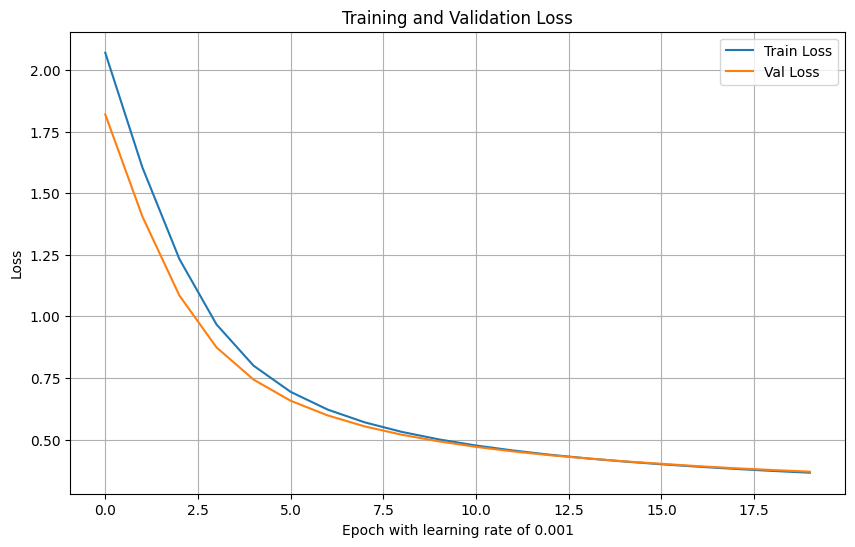

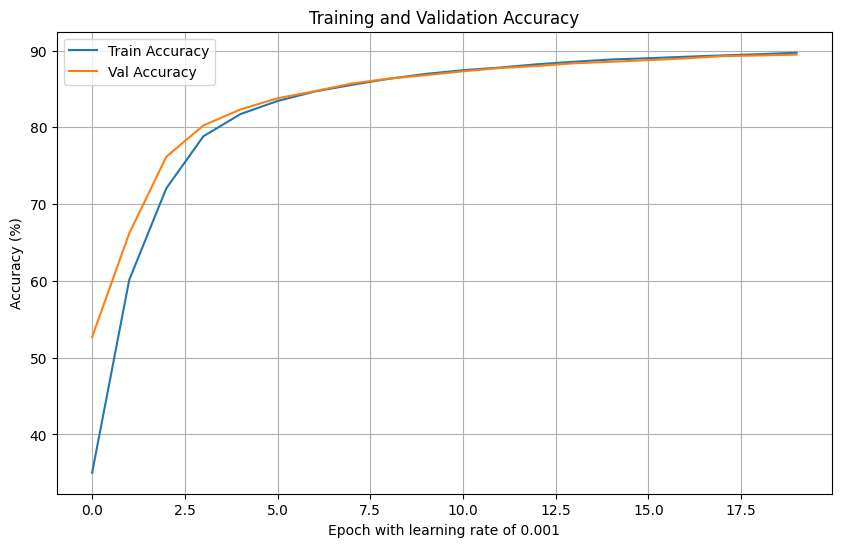

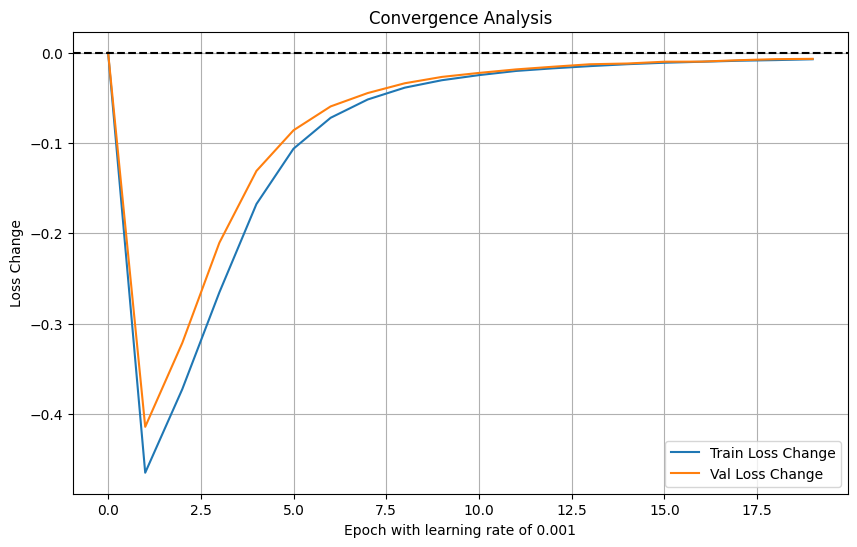

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.0300 | Train Acc: 73.38%
  Val Loss: 0.5255 | Val Acc: 86.21%
Epoch 2/20
  Train Loss: 0.4323 | Train Acc: 88.14%
  Val Loss: 0.3857 | Val Acc: 88.91%
Epoch 3/20
  Train Loss: 0.3519 | Train Acc: 

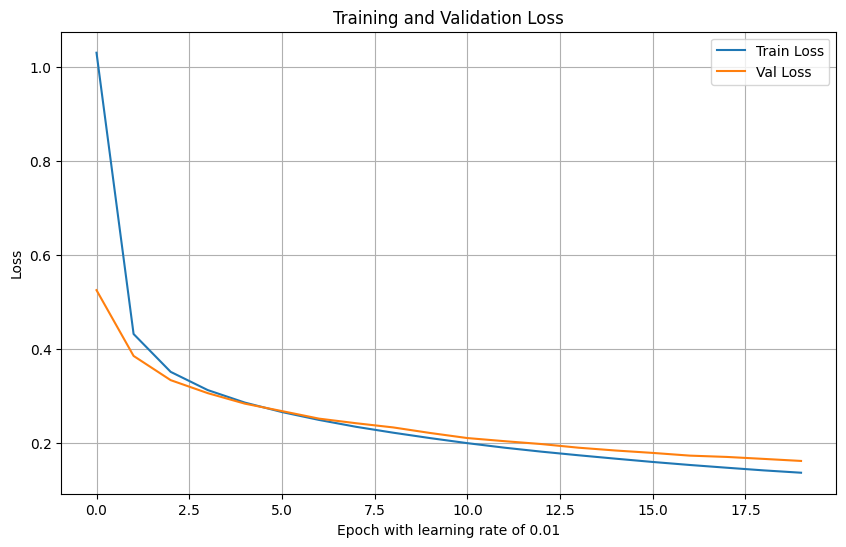

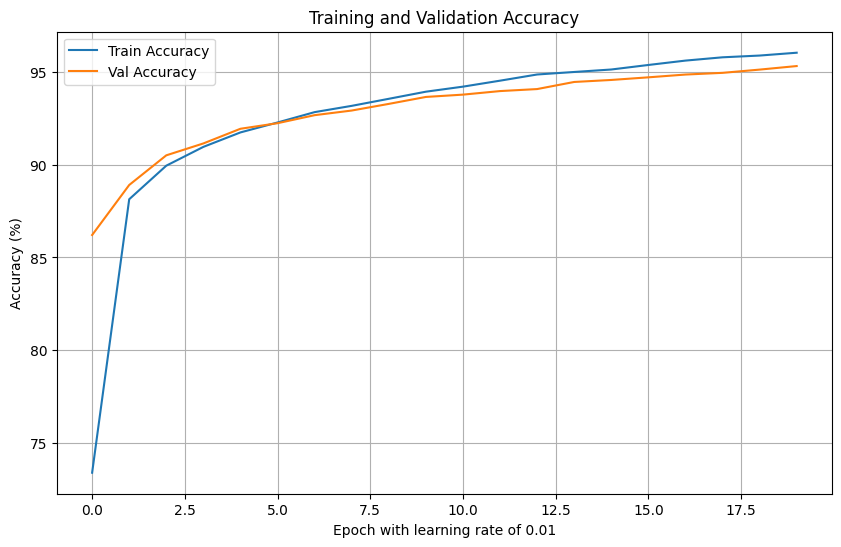

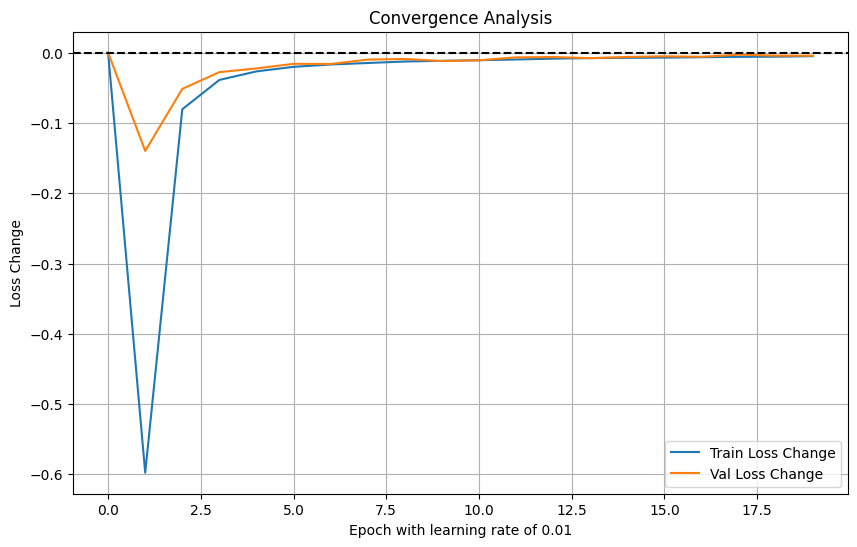

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.3981 | Train Acc: 88.19%
  Val Loss: 0.2550 | Val Acc: 92.44%
Epoch 2/20
  Train Loss: 0.1888 | Train Acc: 94.41%
  Val Loss: 0.1655 | Val Acc: 95.02%
Epoch 3/20
  Train Loss: 0.1369 | Train Acc: 

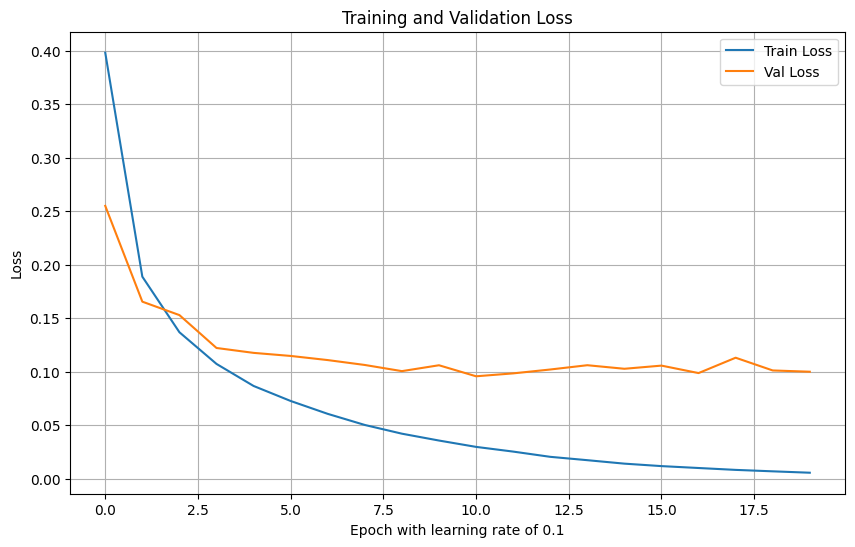

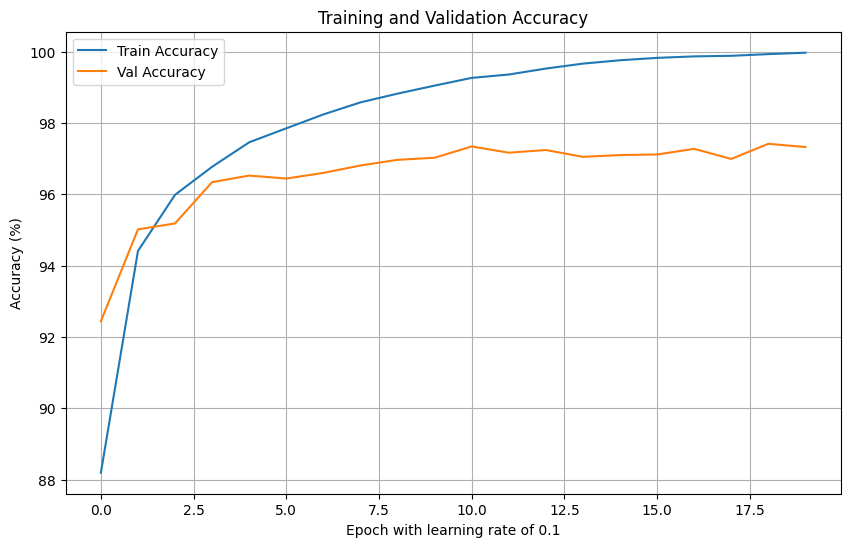

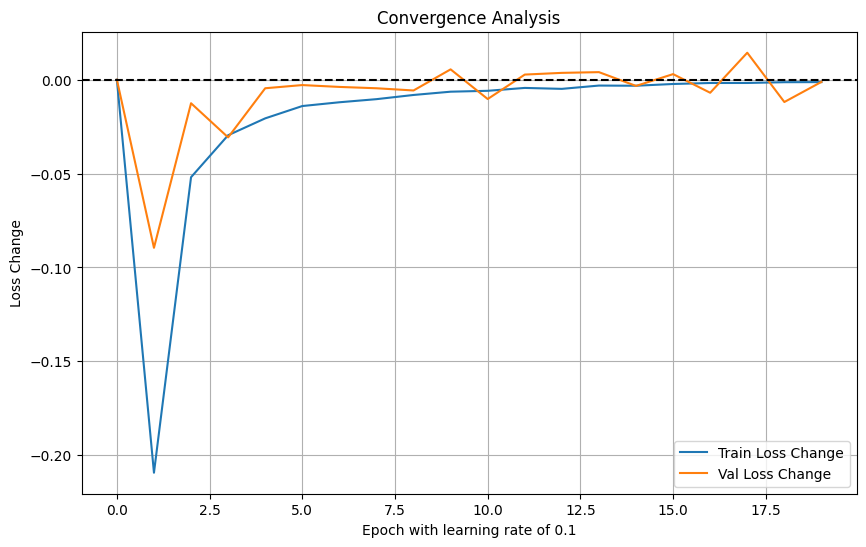

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 2.0496 | Train Acc: 26.19%
  Val Loss: 1.6345 | Val Acc: 38.39%
Epoch 2/20
  Train Loss: 1.6188 | Train Acc: 35.58%
  Val Loss: 1.4682 | Val Acc: 35.80%
Epoch 3/20
  Train Loss: 1.6183 | Train Acc: 

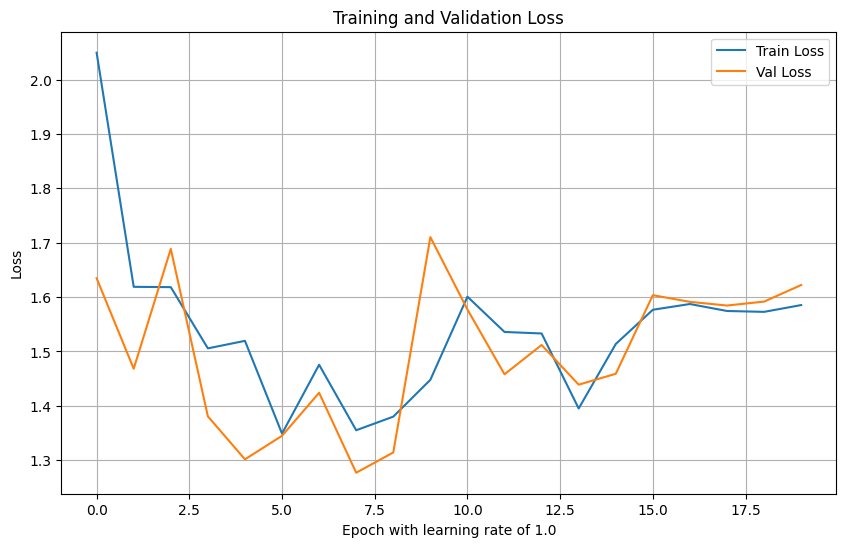

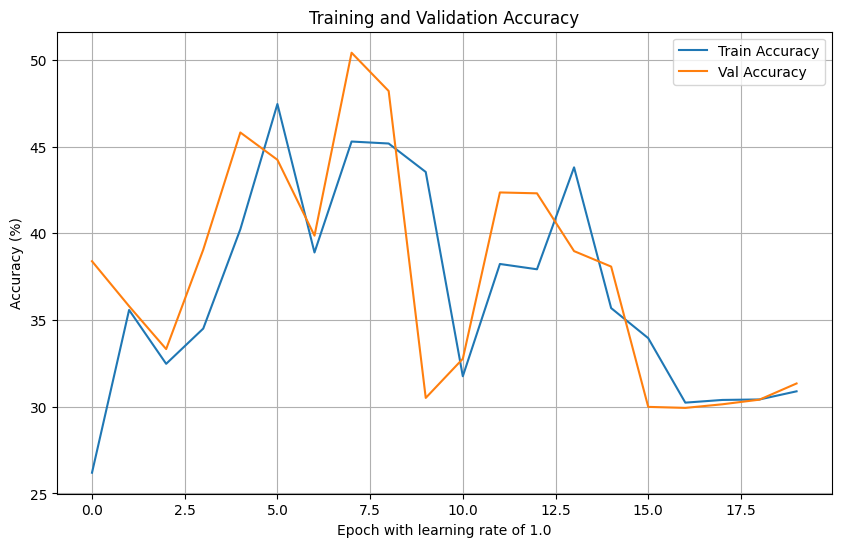

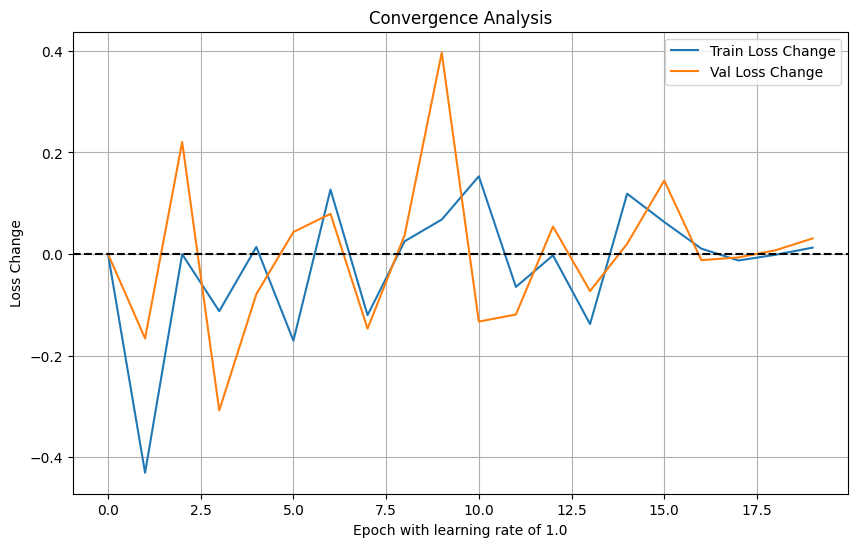

In [14]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
best_val_accuracy = 0
best_learning_rate = None

for learning_rate in learning_rates:
    parameter_setter(learning_rate=learning_rate)
    train_model()

    max_val_acc = max(val_accs)
    if max_val_acc > best_val_accuracy:
        best_val_accuracy = max_val_acc
        best_learning_rate = learning_rate

    plot_loss(f"with learning rate of {learning_rate}")
    plot_acc(f"with learning rate of {learning_rate}")
    plot_converge(f"with learning rate of {learning_rate}")



### getting accuracy of predications using the best learing rate

In [15]:
print(f"\nBest learning rate: {best_learning_rate} with a validation accuracy of {best_val_accuracy:.2f}%")

parameter_setter(learning_rate=best_learning_rate)
train_model()
predict_test()


Best learning rate: 0.1 with a validation accuracy of 97.42%
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.5235 | Train Acc: 84.22%
  Val Loss: 0.2741 | Val Acc: 91.58%
Epoch 2/20
  Train Loss: 0.2190 | Train Acc: 93.54%
  Val Loss: 0.1988 |

### Comparsion between the different learning rates

*   **Learning Rate 0.001:** Slow convergence, stable loss and accuracy curves.
*   **Learning Rate 0.01:** Faster convergence than 0.001, stable loss and accuracy curves. Good balance.
*   **Learning Rate 0.1:** Fast convergence, more change difference in loss and accuracy. Less stable.
*   **Learning Rate 1.0:** Very fast initial convergence, highly unstable loss and accuracy with significant oscillations. Too high.

Learning rate 0.01 appears to be the most suitable.

### batch size

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.6959 | Train Acc: 79.88%
  Val Loss: 0.3525 | Val Acc: 89.67%
Epoch 2/20
  Train Loss: 0.2966 | Train Acc: 91.56%
  Val Loss: 0.2750 | Val Acc: 91.88%
Epoch 3/20
  Train Loss: 0.2366 | Train Acc: 

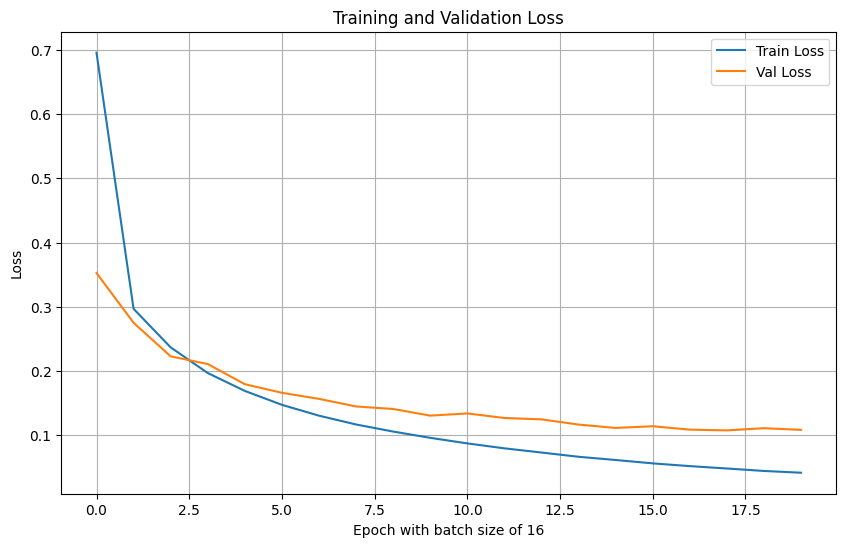

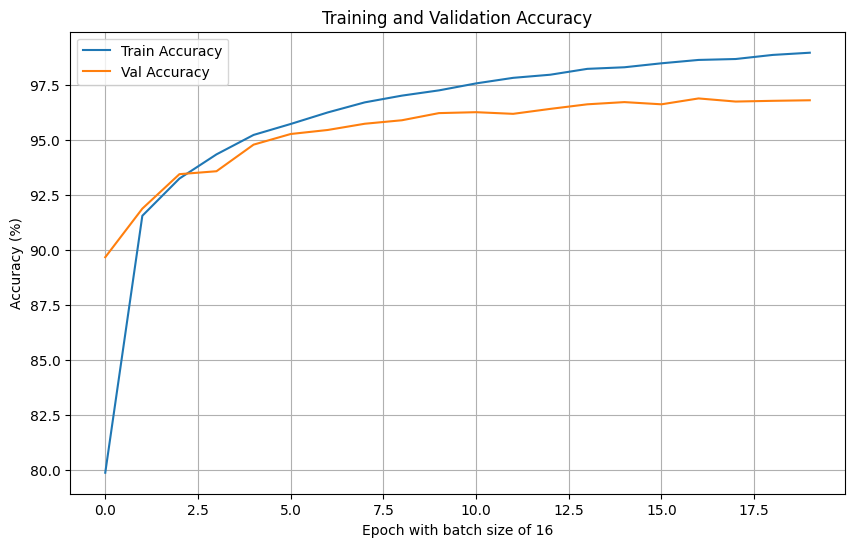

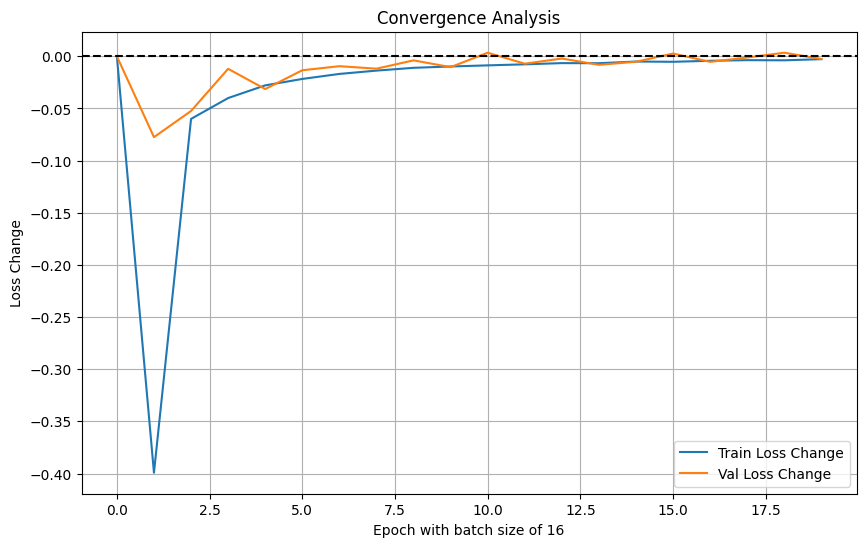

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.9201 | Train Acc: 74.74%
  Val Loss: 0.4263 | Val Acc: 87.99%
Epoch 2/20
  Train Loss: 0.3600 | Train Acc: 89.77%
  Val Loss: 0.3227 | Val Acc: 90.43%
Epoch 3/20
  Train Loss: 0.2966 | Train Acc: 

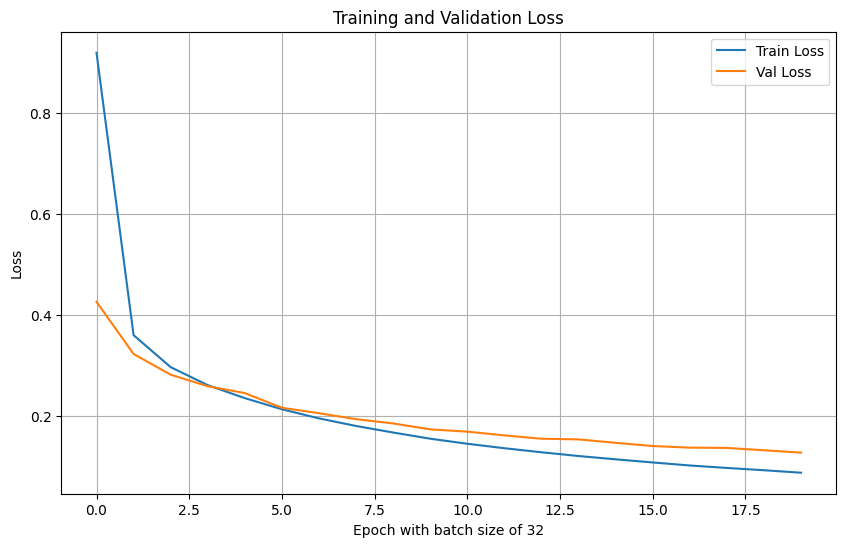

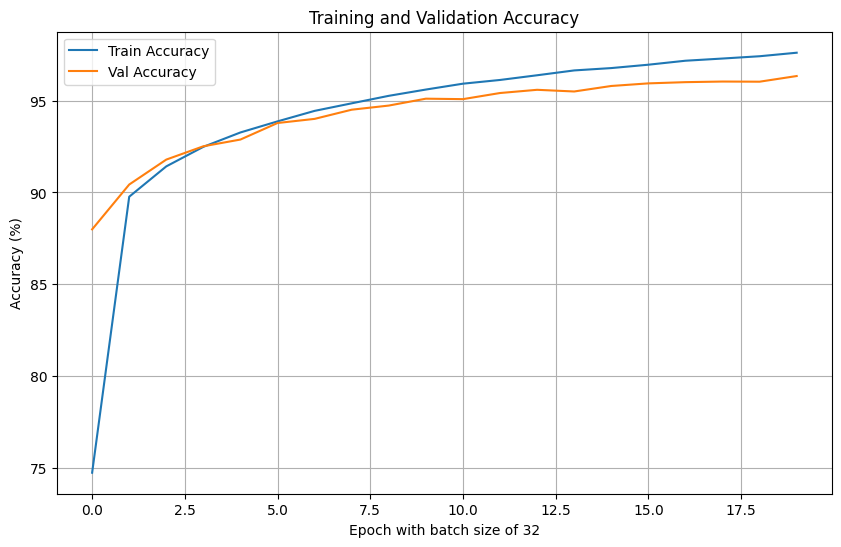

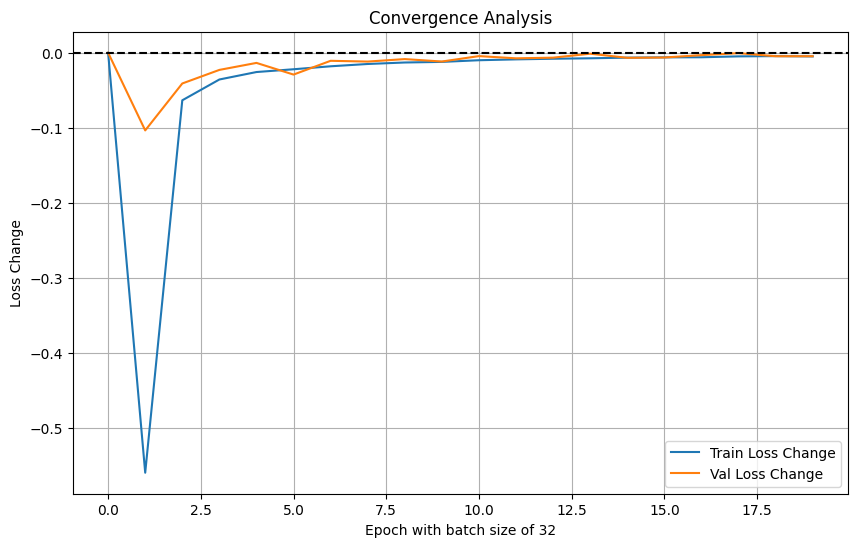

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.4074 | Train Acc: 59.89%
  Val Loss: 0.6995 | Val Acc: 81.08%
Epoch 2/20
  Train Loss: 0.5386 | Train Acc: 85.49%
  Val Loss: 0.4528 | Val Acc: 87.46%
Epoch 3/20
  Train Loss: 0.4014 | Train Acc: 

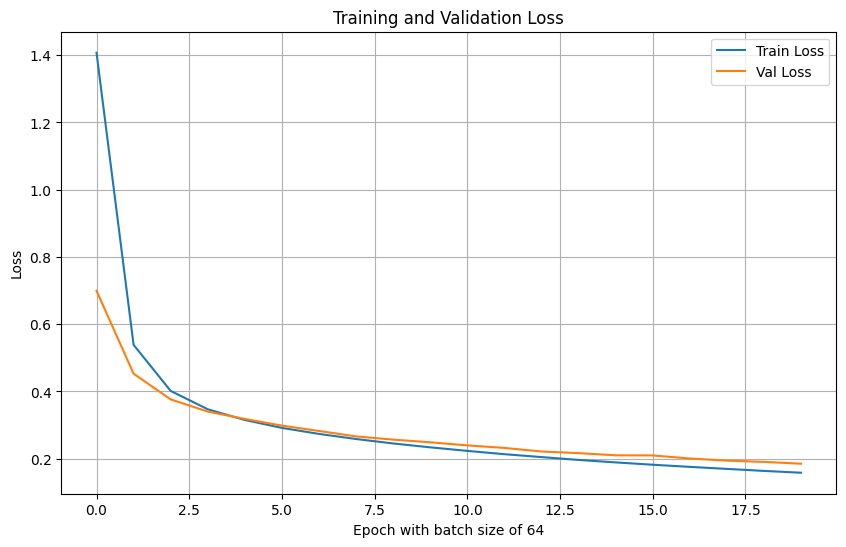

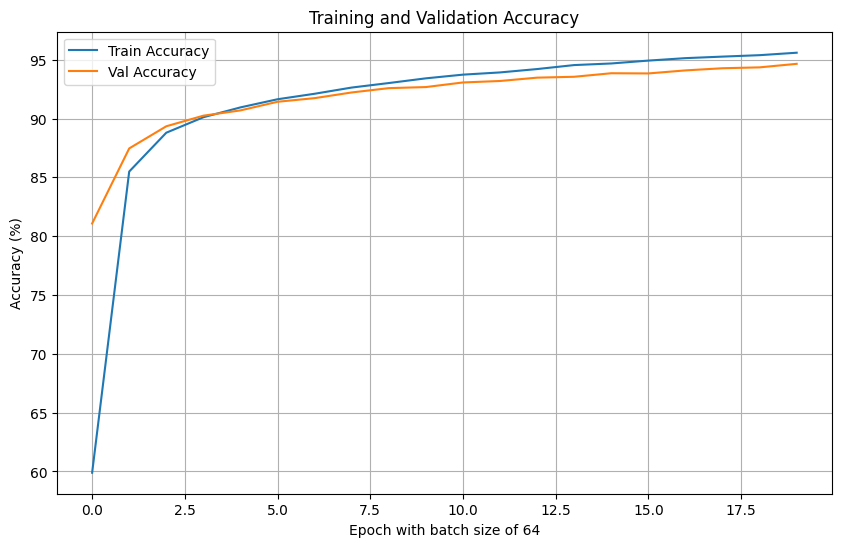

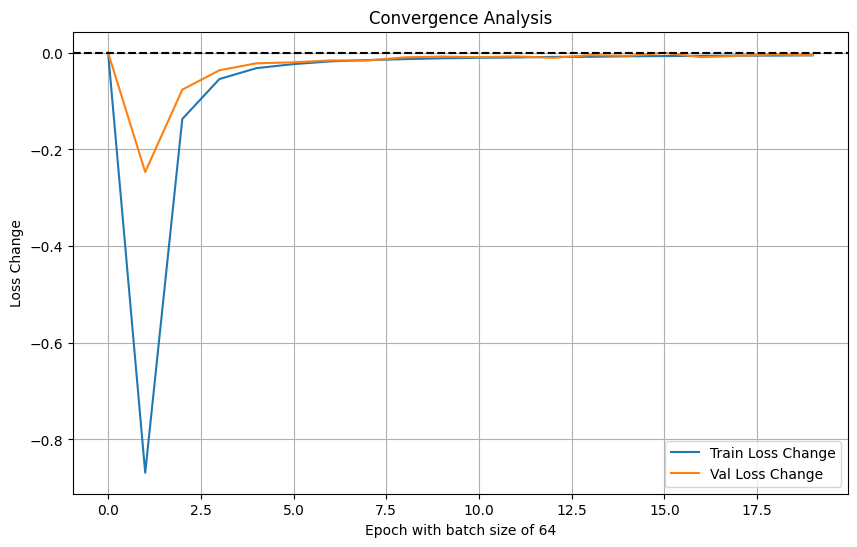

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.9513 | Train Acc: 42.61%
  Val Loss: 1.2332 | Val Acc: 69.91%
Epoch 2/20
  Train Loss: 0.8745 | Train Acc: 78.55%
  Val Loss: 0.6511 | Val Acc: 82.60%
Epoch 3/20
  Train Loss: 0.5559 | Train Acc: 

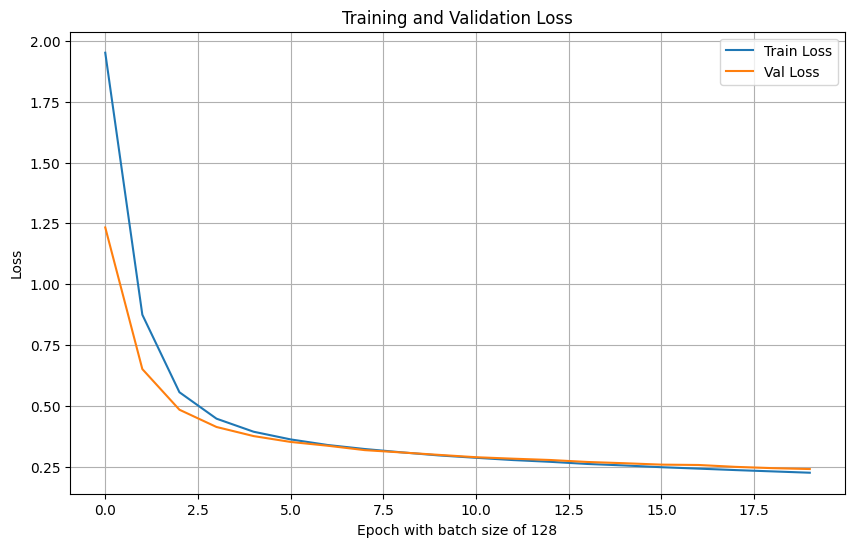

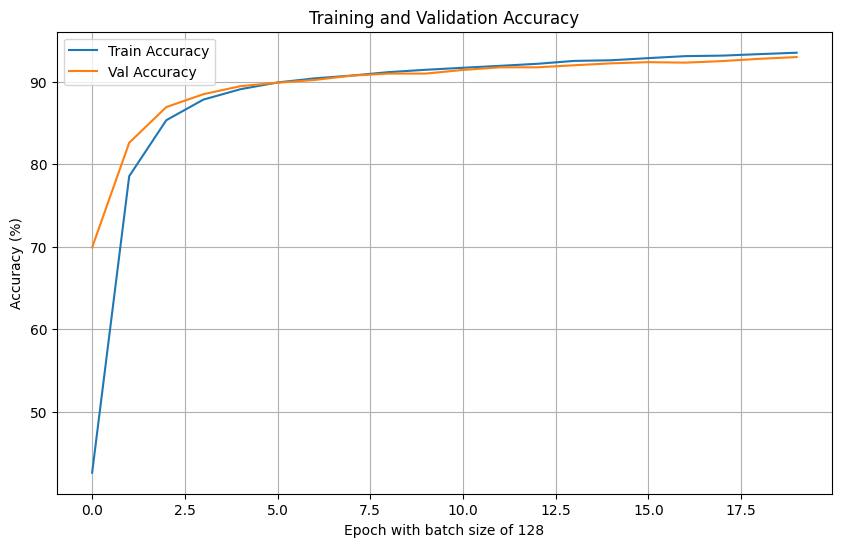

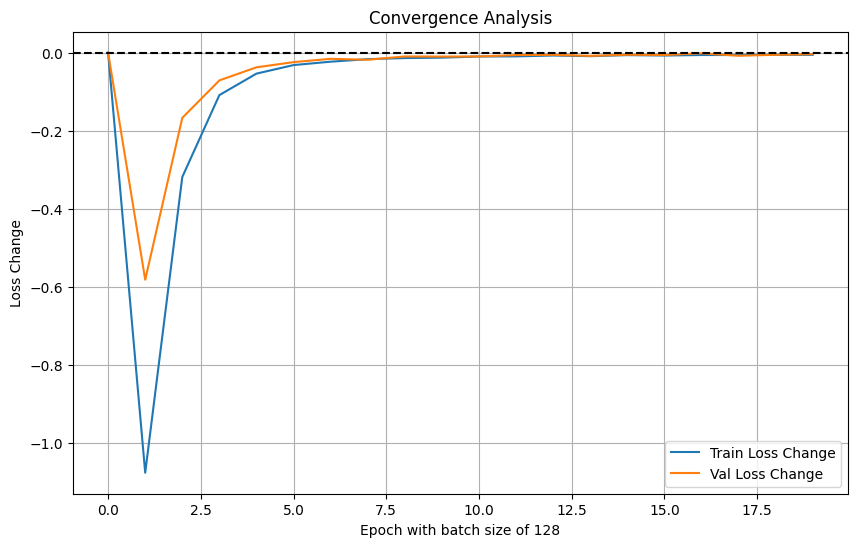


Best batch size: 16 with a validation accuracy of 96.89%


In [16]:
import time

batch_sizes = [16,32,64,128]
best_val_accuracy = 0
best_batch_size = None
training_times = []

for batch_size in batch_sizes:
    parameter_setter(batch_size=batch_size)
    start_time = time.time()
    train_model()
    end_time = time.time()
    training_times.append(end_time - start_time)

    max_val_acc = max(val_accs)
    if max_val_acc > best_val_accuracy:
        best_val_accuracy = max_val_acc
        best_batch_size = batch_size

    plot_loss(f"with batch size of {batch_size}")
    plot_acc(f"with batch size of {batch_size}")
    plot_converge(f"with batch size of {batch_size}")

print(f"\nBest batch size: {best_batch_size} with a validation accuracy of {best_val_accuracy:.2f}%")


### getting accuracy of predications based on the best batch size

In [17]:
print(f"\nBest batch size: {best_batch_size} with a validation accuracy of {best_val_accuracy:.2f}%")

parameter_setter(batch_size=best_batch_size)
train_model()
predict_test()


Best batch size: 16 with a validation accuracy of 96.89%
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.6288 | Train Acc: 82.60%
  Val Loss: 0.3310 | Val Acc: 90.40%
Epoch 2/20
  Train Loss: 0.2908 | Train Acc: 91.56%
  Val Loss: 0.2697 | Val

### ploting the time for training speed

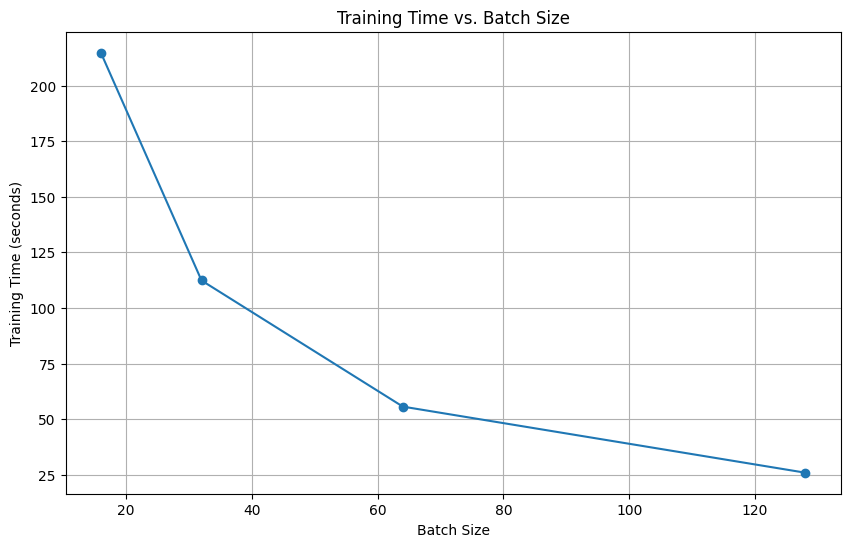

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, training_times, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time vs. Batch Size')
plt.grid(True)
plt.show()



*   **Smaller Batch Sizes (e.g., 16, 32):** has slower time for each epoch but has faster time for each gradient calc
*   **Larger Batch Sizes (e.g., 64, 128):** has faster time for each epoch but has slower time for each gradient calc

Small batches often provide noise that helps generalization (reaches better validation accuracy). -> has more gradient noise

Large batches can converge quickly in terms of loss but sometimes to worse generalization -> has less gradient noise

# Trying different architectures for the neual network

In [19]:
def create_nn_model(num_hidden_layers, neurons_per_layer):
    layers = []
    layers.append(nn.Linear(28 * 28, neurons_per_layer))

    for _ in range(num_hidden_layers):
        layers.append(nn.ReLU())
        layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))

    layers.append(nn.ReLU())
    layers.append(nn.Linear(neurons_per_layer, 10))

    return nn.Sequential(*layers)

## Define hyperparameter setter for architecture




In [20]:
def parameter_setter(learning_rate=.01, num_epochs=20, batch_size=64, num_hidden_layers=2, neurons_per_layer=128):
    global loss_function, optimizer, loader, neural_network, device
    neural_network = create_nn_model(num_hidden_layers, neurons_per_layer)

    for layer in neural_network:
        if isinstance(layer, nn.Linear):
            init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            if layer.bias is not None:
                init.zeros_(layer.bias)


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    neural_network.to(device)

    loss_function = nn.CrossEntropyLoss()
    optimizer = SGD.SGD(neural_network.parameters(), lr=learning_rate)
    loader=dl.build_loader(batch_size)


## Storing the result of the different architectures




In [21]:
import pandas as pd

hidden_layers = [2, 3, 4, 5]
neurons_per_layer_list = [64, 128, 256, 512]

architecture_results = []

for num_hidden_layers in hidden_layers:
    for neurons in neurons_per_layer_list:
        print(f"Training with {num_hidden_layers} hidden layers and {neurons} neurons per layer")
        parameter_setter(num_hidden_layers=num_hidden_layers, neurons_per_layer=neurons)
        train_model()

        architecture_info = {
            'num_hidden_layers': num_hidden_layers,
            'neurons_per_layer': neurons,
            'best_val_accuracy': max(val_accs),
        }
        architecture_results.append(architecture_info)


architecture_data_frame = pd.DataFrame(architecture_results)

print("\n=========Architecture Comparison Table===========\n")
display(architecture_data_frame)

best_architecture = architecture_data_frame.loc[architecture_data_frame['best_val_accuracy'].idxmax()]

print(f"\nBest Architecture:")
print(f"Hidden Layers: {best_architecture['num_hidden_layers']}, Neurons per Layer: {best_architecture['neurons_per_layer']}, Best Val Accuracy: {best_architecture['best_val_accuracy']:.2f}%")

Training with 2 hidden layers and 64 neurons per layer
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.0179 | Train Acc: 71.29%
  Val Loss: 0.4824 | Val Acc: 86.22%
Epoch 2/20
  Train Loss: 0.4042 | Train Acc: 88.40%
  Val Loss: 0.3563 | Val Ac

,num_hidden_layers,neurons_per_layer,best_val_accuracy
0,2,64,95.575000
1,2,128,95.950000
2,2,256,96.500000
3,2,512,96.541667
4,3,64,95.841667
5,3,128,96.466667
6,3,256,96.641667
7,3,512,96.900000
8,4,64,96.175000
9,4,128,96.458333



Best Architecture:
Hidden Layers: 5.0, Neurons per Layer: 512.0, Best Val Accuracy: 97.26%


## getting the Accuracy of predication based on the best architecture

In [22]:

parameter_setter(
    num_hidden_layers=int(best_architecture['num_hidden_layers']),
    neurons_per_layer=int(best_architecture['neurons_per_layer'])
)
train_model()
predict_test()

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.5995 | Train Acc: 83.02%
  Val Loss: 0.3086 | Val Acc: 90.63%
Epoch 2/20
  Train Loss: 0.2415 | Train Acc: 92.77%
  Val Loss: 0.3022 | Val Acc: 90.73%
Epoch 3/20
  Train Loss: 0.1812 | Train Acc: 